## Human Activity Recognition: Gradient Boosting

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize


plt.rcParams.update({'font.size': 12})

### Data Preparation

In [2]:
dataset_dir = Path.cwd() / 'data/UCI HAR Dataset'

X_train = pd.read_csv(dataset_dir / 'train' / 'X_train.txt', sep=r'\s+', header=None)
y_train = pd.read_csv(dataset_dir / 'train' / 'y_train.txt', header=None).iloc[:, 0]
X_test = pd.read_csv(dataset_dir / 'test' / 'X_test.txt', sep=r'\s+', header=None)
y_test = pd.read_csv(dataset_dir / 'test' / 'y_test.txt', header=None).iloc[:, 0]

activity_labels = pd.read_csv(
    dataset_dir / 'activity_labels.txt', sep=r'\s+', header=None, names=['id', 'activity']
)
class_names = activity_labels.sort_values('id')['activity'].tolist()

print('Train shape :', X_train.shape)
print('Test shape  :', X_test.shape)
print('Classes     :', class_names)

Train shape : (7352, 561)
Test shape  : (2947, 561)
Classes     : ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


### Gradient Boosting Model

Model: `HistGradientBoostingClassifier` (gradient boosting over decision trees).

Hyperparameter choice rationale:
- `max_iter=300`: enough boosting stages for stable convergence on HAR-size data;
- `learning_rate=0.07`: conservative step size to reduce overfitting risk;

In [3]:
gb_clf = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.07,
    random_state=42,
)

gb_clf.fit(X_train, y_train)

y_pred = gb_clf.predict(X_test)
y_proba = gb_clf.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f'Accuracy         : {acc:.4f}')
print(f'Precision (macro): {prec:.4f}')
print(f'Recall (macro)   : {rec:.4f}')
print(f'F1-score (macro) : {f1:.4f}')

Accuracy         : 0.9376
Precision (macro): 0.9403
Recall (macro)   : 0.9358
F1-score (macro) : 0.9370


### ROC Curve

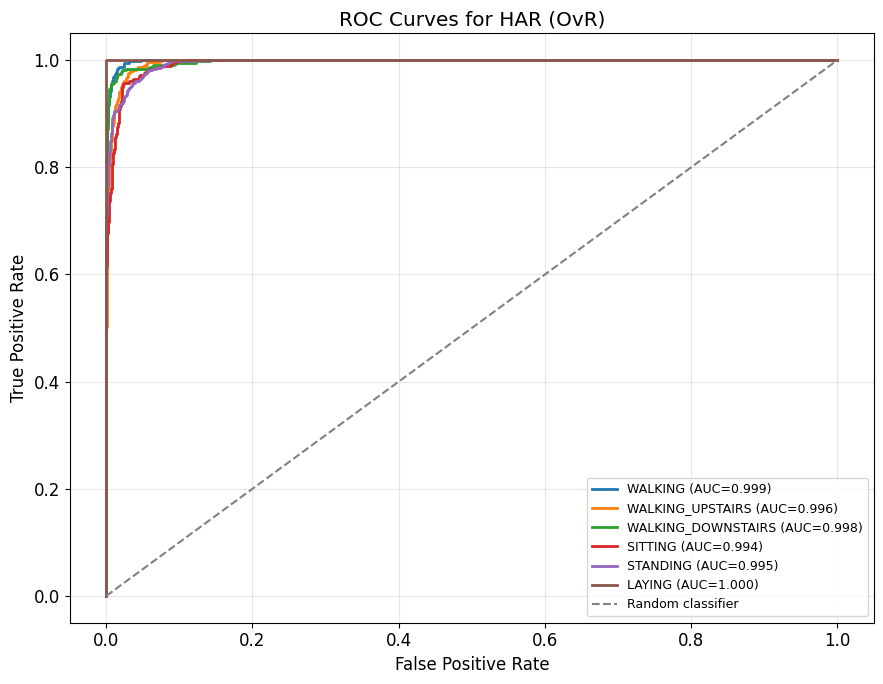

In [6]:
classes = np.array(sorted(y_train.unique()))
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(9, 7))
for i, class_id in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, linewidth=2, label=f"{class_names[class_id - 1]} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for HAR (OvR)')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()